In [16]:
# --- Setup & Data Load ---
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, log_loss
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Dataset shape: {df.shape}")
print(f"Feature names: {data.feature_names.tolist()}")
print(f"Target classes: {data.target_names.tolist()}")
print(f"Class distribution:\n{df['target'].value_counts()}")
df.head()

# Train/test split
X = data.data
y = data.target

X_cv, X_test, y_cv, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nCV pool: {X_cv.shape[0]} samples")
print(f"Test:    {X_test.shape[0]} samples")
print(f"\nCV class dist: {dict(zip(*np.unique(y_cv, return_counts=True)))}")
print(f"Test class dist: {dict(zip(*np.unique(y_test, return_counts=True)))}")

N_FOLDS = 5
kfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)


Dataset shape: (569, 31)
Feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']
Target classes: ['malignant', 'benign']
Class distribution:
target
1    357
0    212
Name: count, dtype: int64

CV pool: 455 samples
Test:    114 samples

CV class dist: {np.int64(0): np.int64(170), np.int64(1): np.int64(285)}
Test class dist: {np.int64(0): np.int64(42), np.int64(1): np.int64(72)}


Fold 1/5  train loss: 0.0108  val loss: 0.0931  val f1: 0.9913
Fold 2/5  train loss: 0.0119  val loss: 0.0779  val f1: 0.9730
Fold 3/5  train loss: 0.0100  val loss: 0.1641  val f1: 0.9558
Fold 4/5  train loss: 0.0104  val loss: 0.1194  val f1: 0.9655
Fold 5/5  train loss: 0.0111  val loss: 0.0515  val f1: 0.9825

Baseline XGBoost CV F1: 0.9736 ± 0.0125


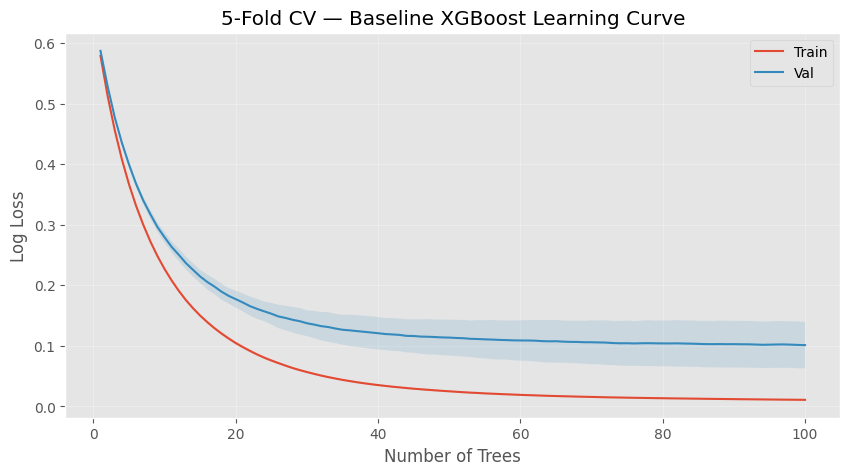

In [17]:
# --- Baseline XGBoost — 5-Fold CV with Learning Curves ---
baseline_params = {
    'n_estimators': 100,
    'max_depth': 4,
    'learning_rate': 0.1,
    'eval_metric': 'logloss',
    'random_state': 42,
}

all_train_losses = []
all_val_losses = []
baseline_val_f1s = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_cv, y_cv)):
    X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
    y_tr, y_val = y_cv[train_idx], y_cv[val_idx]
    
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_val_s = scaler.transform(X_val)
    
    model = xgb.XGBClassifier(**baseline_params)
    model.fit(X_tr_s, y_tr,
              eval_set=[(X_tr_s, y_tr), (X_val_s, y_val)],
              verbose=False)
    
    evals = model.evals_result()
    train_loss = evals['validation_0']['logloss']
    val_loss = evals['validation_1']['logloss']
    
    all_train_losses.append(train_loss)
    all_val_losses.append(val_loss)
    
    y_pred = model.predict(X_val_s)
    val_f1 = f1_score(y_val, y_pred)
    baseline_val_f1s.append(val_f1)
    print(f"Fold {fold+1}/{N_FOLDS}  train loss: {train_loss[-1]:.4f}  val loss: {val_loss[-1]:.4f}  val f1: {val_f1:.4f}")

print(f"\nBaseline XGBoost CV F1: {np.mean(baseline_val_f1s):.4f} \u00b1 {np.std(baseline_val_f1s):.4f}")

# --- Learning curves ---
all_train = np.array(all_train_losses)
all_val = np.array(all_val_losses)

train_mean = all_train.mean(axis=0)
train_std  = all_train.std(axis=0)
val_mean   = all_val.mean(axis=0)
val_std    = all_val.std(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
trees = np.arange(1, len(train_mean) + 1)

ax.plot(trees, train_mean, label='Train')
ax.fill_between(trees, train_mean - train_std, train_mean + train_std, alpha=0.15)
ax.plot(trees, val_mean, label='Val')
ax.fill_between(trees, val_mean - val_std, val_mean + val_std, alpha=0.15)
ax.set_xlabel('Number of Trees')
ax.set_ylabel('Log Loss')
ax.set_title(f'{N_FOLDS}-Fold CV — Baseline XGBoost Learning Curve')
ax.legend()
ax.grid(alpha=0.3)
plt.show()


In [18]:
pip install optuna 


Best trial (#25):
  Value (mean CV F1): 0.9825
  Params:
    n_estimators: 250
    max_depth: 6
    learning_rate: 0.072562622872946
    subsample: 0.7154648530504842
    colsample_bytree: 0.6353178853923681
    reg_lambda: 0.016072303745730175
    reg_alpha: 0.9171246450335802


/tmp/ipykernel_10078/1792735892.py:49: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


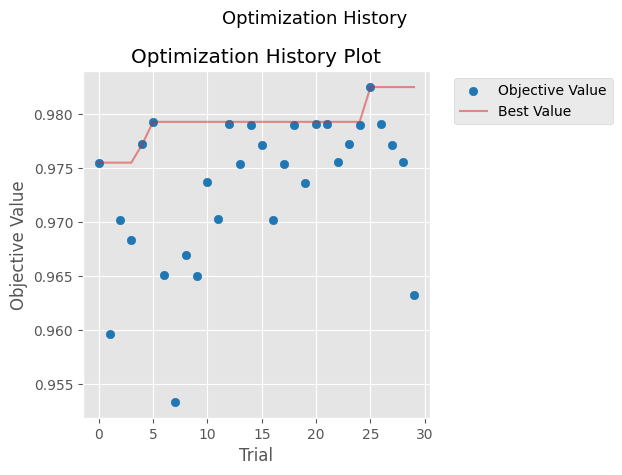

/tmp/ipykernel_10078/1792735892.py:53: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


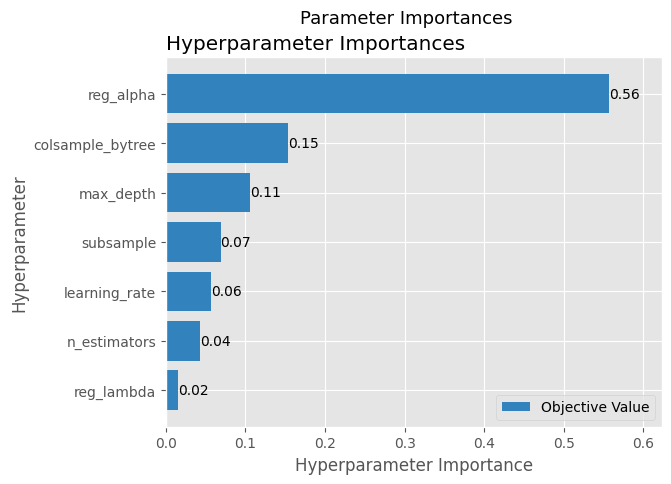

/tmp/ipykernel_10078/1792735892.py:57: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study)


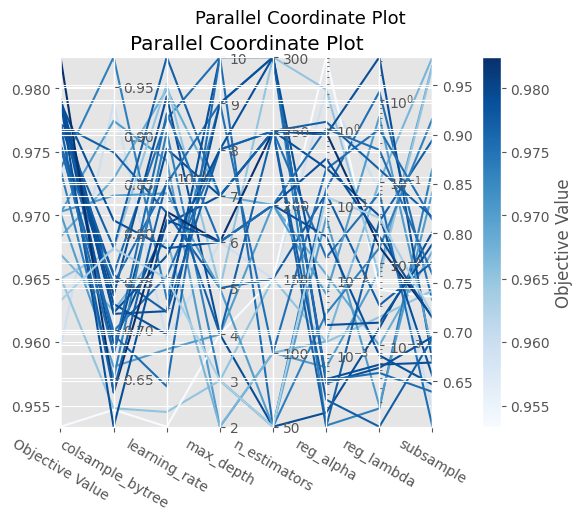

/tmp/ipykernel_10078/1792735892.py:61: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study)
/tmp/ipykernel_10078/1792735892.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


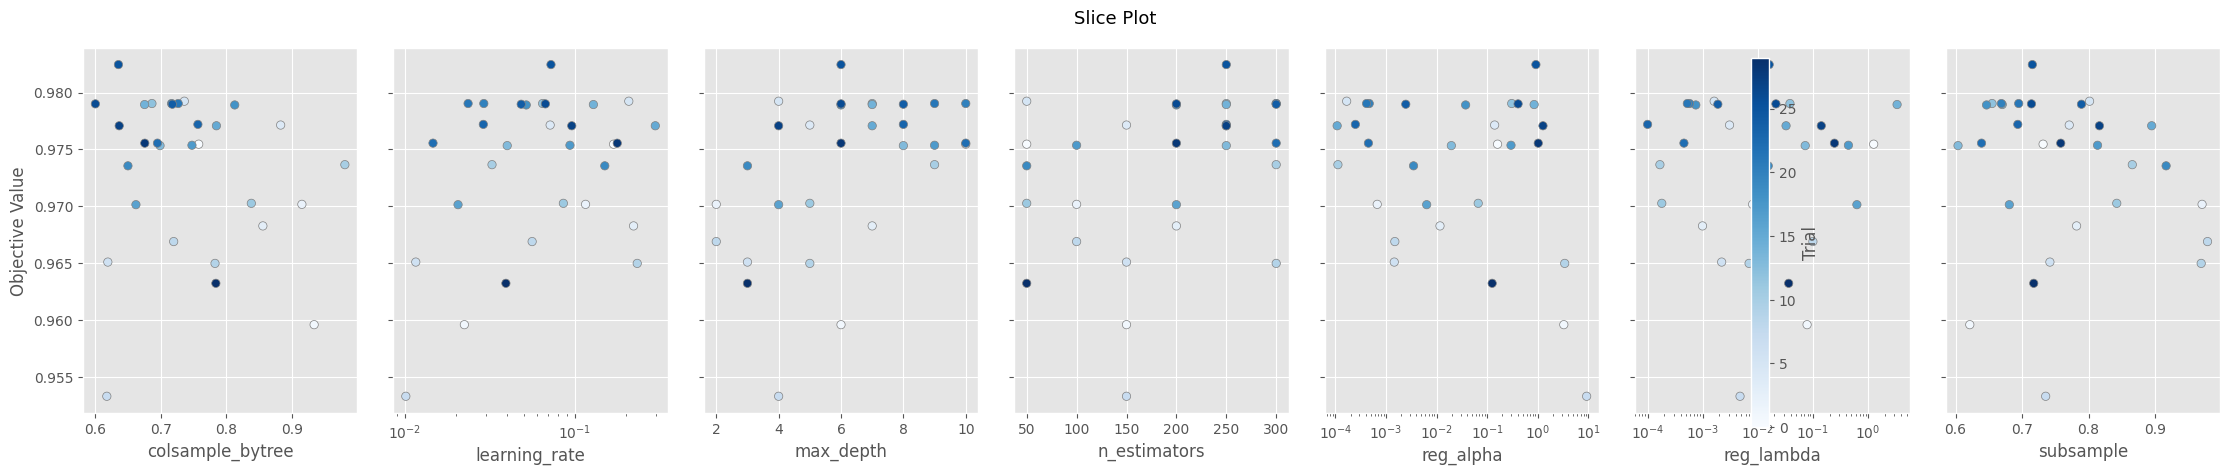

In [19]:
# --- Optuna Hyperparameter Tuning — XGBoost ---
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
    }

    fold_val_f1s = []

    for train_idx, val_idx in kfold.split(X_cv, y_cv):
        X_tr, X_val = X_cv[train_idx], X_cv[val_idx]
        y_tr, y_val = y_cv[train_idx], y_cv[val_idx]

        scaler = StandardScaler()
        X_tr_s = scaler.fit_transform(X_tr)
        X_val_s = scaler.transform(X_val)

        model = xgb.XGBClassifier(**params)
        model.fit(X_tr_s, y_tr, verbose=False)

        y_pred = model.predict(X_val_s)
        fold_val_f1s.append(f1_score(y_val, y_pred))

    return np.mean(fold_val_f1s)


N_TRIALS = 30
study = optuna.create_study(direction='maximize',
                            pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=N_TRIALS)

print(f"\nBest trial (#{study.best_trial.number}):")
print(f"  Value (mean CV F1): {study.best_value:.4f}")
print(f"  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# --- Optuna charts ---
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.gcf().suptitle('Optimization History', fontsize=13)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.gcf().suptitle('Parameter Importances', fontsize=13)
plt.show()

optuna.visualization.matplotlib.plot_parallel_coordinate(study)
plt.gcf().suptitle('Parallel Coordinate Plot', fontsize=13)
plt.show()

optuna.visualization.matplotlib.plot_slice(study)
plt.gcf().suptitle('Slice Plot', fontsize=13)
plt.tight_layout()
plt.show()



               Baseline      Tuned
     Test F1     0.9589     0.9589
   Precision     0.9459     0.9459
      Recall     0.9722     0.9722
    Log Loss     0.1003     0.0973

Confusion Matrices:
  Baseline: TN=38  FP=4  FN=2  TP=70
     Tuned: TN=38  FP=4  FN=2  TP=70


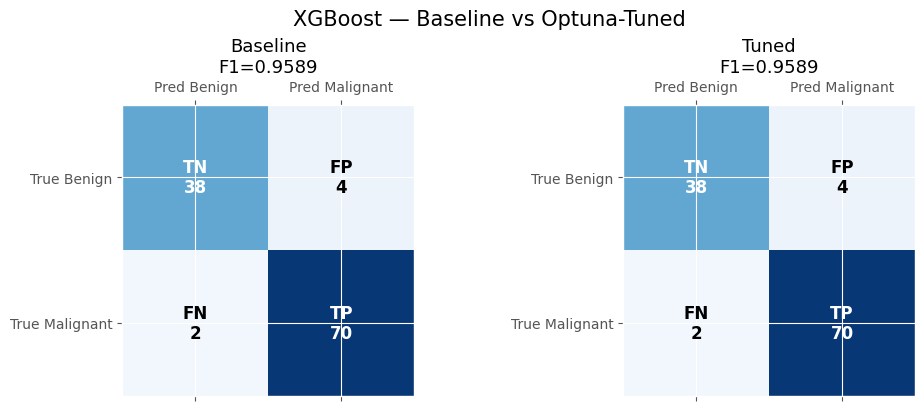

In [20]:
# --- Test-Set Evaluation — Baseline vs Tuned XGBoost ---

# Fit scaler on full CV
scaler_final = StandardScaler()
X_cv_s = scaler_final.fit_transform(X_cv)
X_test_s = scaler_final.transform(X_test)

def evaluate_xgb(params, label):
    model = xgb.XGBClassifier(**params)
    model.fit(X_cv_s, y_cv, verbose=False)
    
    y_pred = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:, 1]
    
    f1 = f1_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    ll = log_loss(y_test, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    return {'label': label, 'f1': f1, 'precision': prec, 'recall': rec,
            'log_loss': ll, 'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp}

bp = study.best_params
tuned_params = {
    'n_estimators': bp['n_estimators'],
    'max_depth': bp['max_depth'],
    'learning_rate': bp['learning_rate'],
    'subsample': bp['subsample'],
    'colsample_bytree': bp['colsample_bytree'],
    'reg_lambda': bp['reg_lambda'],
    'reg_alpha': bp['reg_alpha'],
    'eval_metric': 'logloss',
    'random_state': 42,
}

r_base = evaluate_xgb(baseline_params, 'Baseline')
r_tune = evaluate_xgb(tuned_params, 'Tuned')

# --- Comparison table ---
print(f"\n{'':>12} {'Baseline':>10} {'Tuned':>10}")
print(f"{'Test F1':>12} {r_base['f1']:>10.4f} {r_tune['f1']:>10.4f}")
print(f"{'Precision':>12} {r_base['precision']:>10.4f} {r_tune['precision']:>10.4f}")
print(f"{'Recall':>12} {r_base['recall']:>10.4f} {r_tune['recall']:>10.4f}")
print(f"{'Log Loss':>12} {r_base['log_loss']:>10.4f} {r_tune['log_loss']:>10.4f}")

print(f"\nConfusion Matrices:")
for r in [r_base, r_tune]:
    print(f"  {r['label']:>8}: TN={r['tn']:.0f}  FP={r['fp']:.0f}  FN={r['fn']:.0f}  TP={r['tp']:.0f}")

# --- Visual ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

for ax, r in zip(axes, [r_base, r_tune]):
    cm = np.array([[r['tn'], r['fp']], [r['fn'], r['tp']]])
    im = ax.matshow(cm, cmap='Blues', vmin=0, vmax=72)
    ax.set_title(f"{r['label']}\nF1={r['f1']:.4f}", fontsize=13)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Pred Benign', 'Pred Malignant'])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['True Benign', 'True Malignant'])
    for (i, j), val in np.ndenumerate(cm):
        label = "TN" if i==0 and j==0 else "FP" if i==0 else "FN" if j==0 else "TP"
        ax.text(j, i, f"{label}\n{val:.0f}", ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='white' if val > 36 else 'black')

fig.suptitle('XGBoost — Baseline vs Optuna-Tuned', fontsize=15)
plt.show()


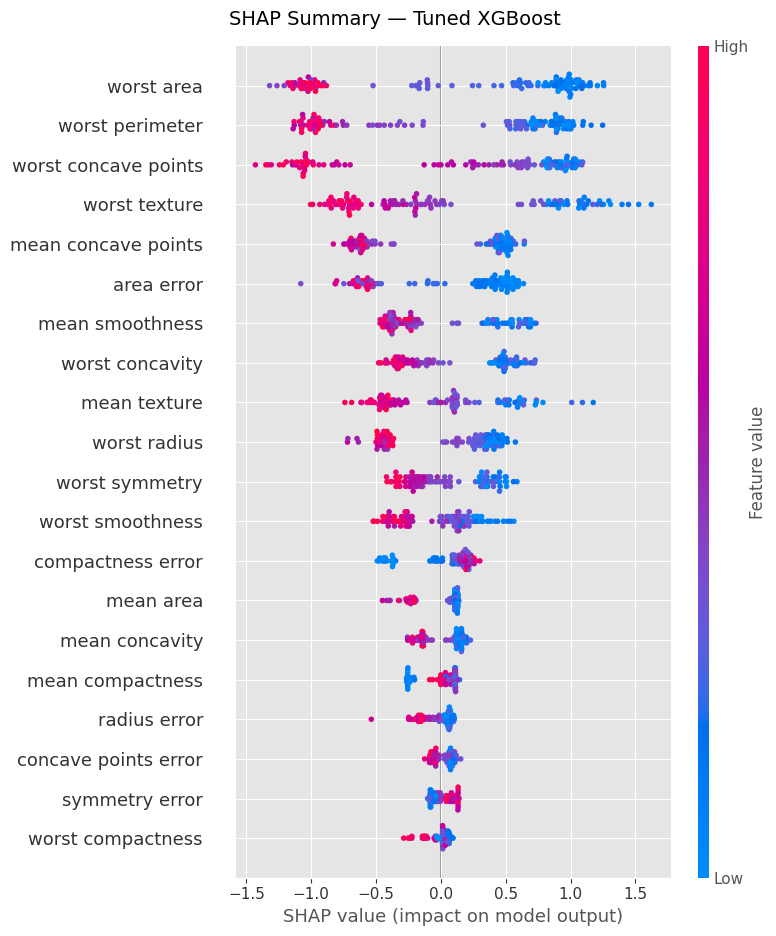

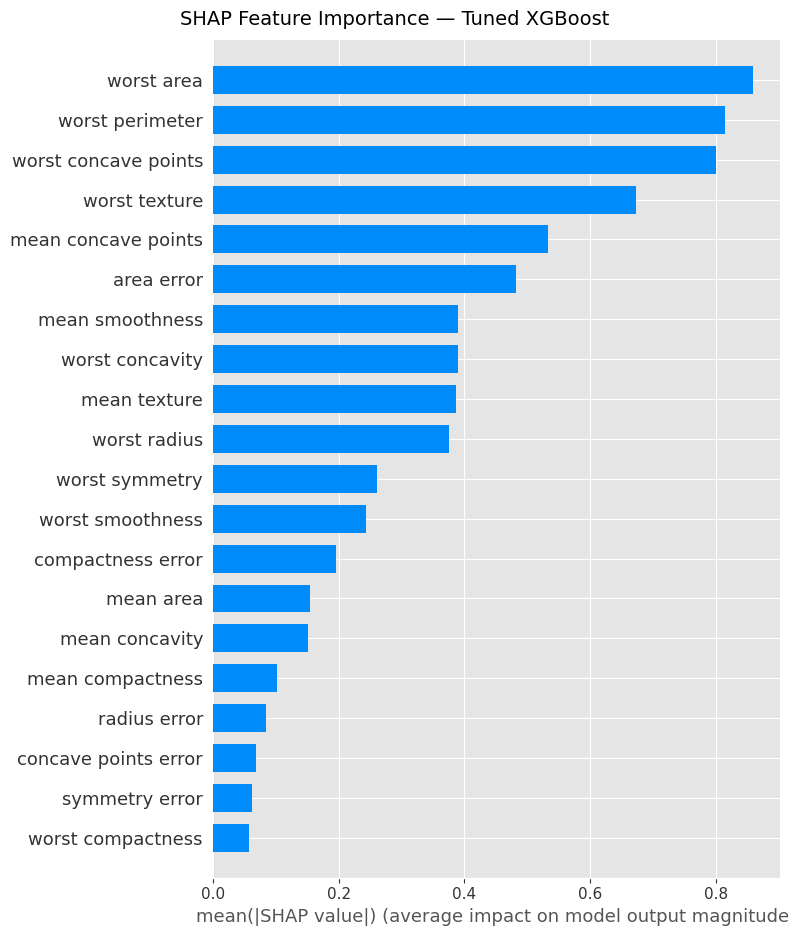

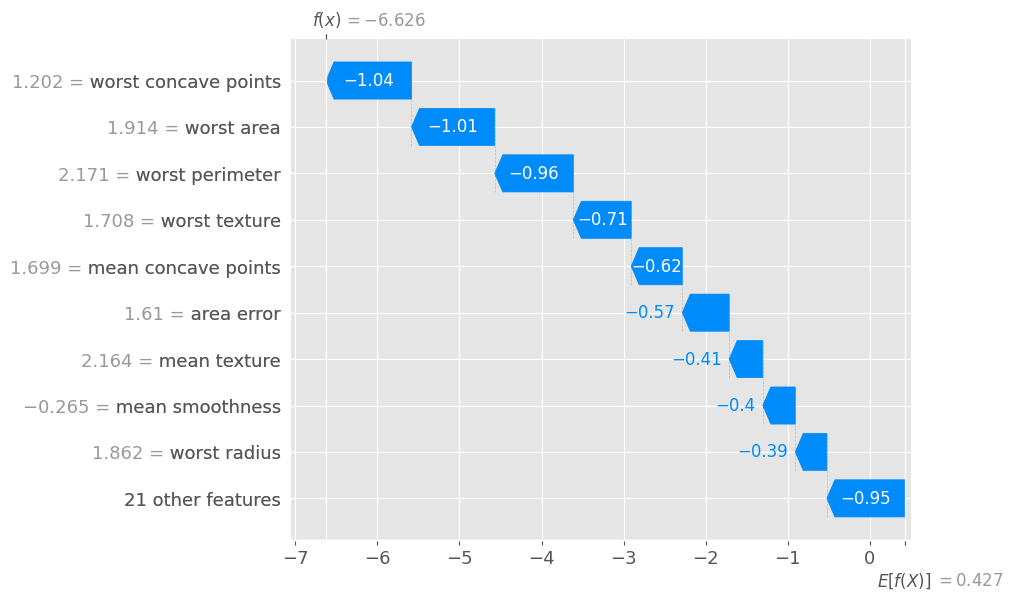

<Figure size 640x480 with 0 Axes>

In [21]:
# --- SHAP Analysis — Tuned XGBoost ---
import shap

# Build tuned model on full CV
bp = study.best_params
xgb_tuned = xgb.XGBClassifier(
    n_estimators=bp['n_estimators'],
    max_depth=bp['max_depth'],
    learning_rate=bp['learning_rate'],
    subsample=bp['subsample'],
    colsample_bytree=bp['colsample_bytree'],
    reg_lambda=bp['reg_lambda'],
    reg_alpha=bp['reg_alpha'],
    eval_metric='logloss',
    random_state=42,
)
xgb_tuned.fit(X_cv_s, y_cv, verbose=False)

explainer = shap.TreeExplainer(xgb_tuned)
shap_values = explainer.shap_values(X_test_s)

# Beeswarm summary plot
shap.summary_plot(shap_values, X_test_s, feature_names=data.feature_names, show=False)
plt.gcf().suptitle('SHAP Summary — Tuned XGBoost', fontsize=14)
plt.tight_layout()
plt.show()

# Bar plot — mean absolute SHAP
shap.summary_plot(shap_values, X_test_s, feature_names=data.feature_names, plot_type='bar', show=False)
plt.gcf().suptitle('SHAP Feature Importance — Tuned XGBoost', fontsize=14)
plt.tight_layout()
plt.show()

# Waterfall — single prediction (first test sample)
shap.waterfall_plot(shap.Explanation(values=shap_values[0],
                                     base_values=explainer.expected_value,
                                     data=X_test_s[0],
                                     feature_names=data.feature_names))
plt.gcf().suptitle(f'SHAP Waterfall — Sample 0 (True: {data.target_names[y_test[0]]})', fontsize=13)
plt.tight_layout()
plt.show()


In [22]:
# --- Model Card ---
from IPython.display import HTML, display

bp = study.best_params

# Build HTML model card
html = """
<div style="max-width:720px; font-family:-apple-system,Segoe UI,sans-serif; background:linear-gradient(135deg,#f8f9fa 0%,#e9ecef 100%); border-radius:16px; padding:28px 32px; box-shadow:0 4px 24px rgba(0,0,0,0.12); border:1px solid #dee2e6;">

<h2 style="text-align:center; color:#1a1a2e; margin:0 0 4px 0; font-size:22px;">Breast Cancer Diagnostic Model</h2>
<p style="text-align:center; color:#6c757d; font-size:13px; margin:0 0 20px 0;">Binary classification · Wisconsin Diagnostic Dataset</p>

<div style="display:flex; gap:20px; margin-bottom:20px;">
  <div style="flex:1; background:#fff; border-radius:10px; padding:16px; box-shadow:0 1px 4px rgba(0,0,0,0.06);">
    <h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Dataset</h4>
    <table style="width:100%; font-size:13px; border-collapse:collapse;">
      <tr><td style="color:#6c757d; padding:3px 6px;">Samples</td><td style="text-align:right; font-weight:600;">569</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Features</td><td style="text-align:right; font-weight:600;">30 (real-valued)</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Train (CV)</td><td style="text-align:right; font-weight:600;">455</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Test (holdout)</td><td style="text-align:right; font-weight:600;">114</td></tr>
      <tr><td style="color:#6c757d; padding:3px 6px;">Split</td><td style="text-align:right; font-weight:600;">80/20 stratified</td></tr>
    </table>
  </div>
  <div style="flex:1; background:#fff; border-radius:10px; padding:16px; box-shadow:0 1px 4px rgba(0,0,0,0.06);">
    <h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Architecture</h4>
    <div style="text-align:center; font-family:monospace; font-size:13px; line-height:1.8; color:#212529;">
      <b>XGBoost Ensemble</b><br>
      <span style="display:inline-block;border:1px solid #adb5bd;border-radius:6px;padding:3px 14px;">{n_estimators} trees</span><br>
      &darr;<br>
      <span style="display:inline-block;background:#e7f5ff;border-radius:6px;padding:3px 12px;">max_depth {max_depth}</span><br>
      &darr;<br>
      <span style="display:inline-block;border:1px solid #adb5bd;border-radius:6px;padding:3px 14px;">Binary logloss</span>
    </div>
  </div>
</div>

<h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Best Hyperparameters <span style="font-size:11px; color:#adb5bd;">(Optuna — 30 trials, mean CV F1)</span></h4>
<table style="width:100%; font-size:13px; border-collapse:collapse; background:#fff; border-radius:10px; overflow:hidden; box-shadow:0 1px 4px rgba(0,0,0,0.06); margin-bottom:16px;">
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">n_estimators</td>
    <td style="padding:8px 12px;">{n_estimators}</td>
    <td style="padding:8px 12px; font-weight:600;">learning_rate</td>
    <td style="padding:8px 12px;">{lr:.4f}</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">max_depth</td>
    <td style="padding:8px 12px;">{max_depth}</td>
    <td style="padding:8px 12px; font-weight:600;">subsample</td>
    <td style="padding:8px 12px;">{subsample:.3f}</td>
  </tr>
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">colsample_bytree</td>
    <td style="padding:8px 12px;">{colsample_bytree:.3f}</td>
    <td style="padding:8px 12px; font-weight:600;">reg_lambda</td>
    <td style="padding:8px 12px;">{reg_lambda:.4f}</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">reg_alpha</td>
    <td style="padding:8px 12px;">{reg_alpha:.4f}</td>
    <td style="padding:8px 12px; font-weight:600;">Cross-Validation</td>
    <td style="padding:8px 12px;">5-fold stratified</td>
  </tr>
</table>

<h4 style="margin:0 0 8px 0; color:#495057; font-size:14px;">Test-Set Performance</h4>
<table style="width:100%; font-size:13px; border-collapse:collapse; background:#fff; border-radius:10px; overflow:hidden; box-shadow:0 1px 4px rgba(0,0,0,0.06); margin-bottom:16px;">
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;"></td>
    <td style="padding:8px 12px; font-weight:600; text-align:center;">Baseline</td>
    <td style="padding:8px 12px; font-weight:600; text-align:center; background:#d3f9d8;">Tuned ★</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">F1 Score</td>
    <td style="padding:8px 12px; text-align:center;">{base_f1:.4f}</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">{tune_f1:.4f}</td>
  </tr>
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">Precision</td>
    <td style="padding:8px 12px; text-align:center;">{base_prec:.4f}</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">{tune_prec:.4f}</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">Recall</td>
    <td style="padding:8px 12px; text-align:center;">{base_rec:.4f}</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">{tune_rec:.4f}</td>
  </tr>
  <tr style="background:#f1f3f5;">
    <td style="padding:8px 12px; font-weight:600;">Log Loss</td>
    <td style="padding:8px 12px; text-align:center;">{base_ll:.4f}</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">{tune_ll:.4f}</td>
  </tr>
  <tr>
    <td style="padding:8px 12px; font-weight:600;">TP / FP / FN</td>
    <td style="padding:8px 12px; text-align:center;">{base_tp:.0f} / {base_fp:.0f} / {base_fn:.0f}</td>
    <td style="padding:8px 12px; text-align:center; background:#d3f9d8; font-weight:600;">{tune_tp:.0f} / {tune_fp:.0f} / {tune_fn:.0f}</td>
  </tr>
</table>

<div style="display:flex; gap:12px; margin-top:16px;">
  <div style="flex:1; background:#d3f9d8; border-radius:8px; padding:10px 14px; text-align:center;">
    <div style="font-size:11px; color:#2b8a3e; text-transform:uppercase; font-weight:600;">Tree Ensemble</div>
    <div style="font-size:13px; color:#212529; margin-top:2px;">{n_estimators} trees<br>max_depth {max_depth}</div>
  </div>
  <div style="flex:1; background:#e7f5ff; border-radius:8px; padding:10px 14px; text-align:center;">
    <div style="font-size:11px; color:#1971c2; text-transform:uppercase; font-weight:600;">Validation</div>
    <div style="font-size:13px; color:#212529; margin-top:2px;">5-fold stratified CV<br>Mean F1 optimized</div>
  </div>
  <div style="flex:1; background:#fff9db; border-radius:8px; padding:10px 14px; text-align:center;">
    <div style="font-size:11px; color:#e67700; text-transform:uppercase; font-weight:600;">Preprocessing</div>
    <div style="font-size:13px; color:#212529; margin-top:2px;">StandardScaler<br>Fit on train only</div>
  </div>
</div>

<p style="text-align:center; color:#adb5bd; font-size:11px; margin:16px 0 0 0;">XGBoost · Gradient-Boosted Trees · Optimized with Optuna</p>
</div>
"""

html = html.format(
    n_estimators=bp['n_estimators'],
    max_depth=bp['max_depth'],
    lr=bp['learning_rate'],
    subsample=bp['subsample'],
    colsample_bytree=bp['colsample_bytree'],
    reg_lambda=bp['reg_lambda'],
    reg_alpha=bp['reg_alpha'],
    base_f1=r_base['f1'],
    base_prec=r_base['precision'],
    base_rec=r_base['recall'],
    base_ll=r_base['log_loss'],
    base_tp=r_base['tp'],
    base_fp=r_base['fp'],
    base_fn=r_base['fn'],
    tune_f1=r_tune['f1'],
    tune_prec=r_tune['precision'],
    tune_rec=r_tune['recall'],
    tune_ll=r_tune['log_loss'],
    tune_tp=r_tune['tp'],
    tune_fp=r_tune['fp'],
    tune_fn=r_tune['fn'],
)

display(HTML(html))

In [23]:
# --- Save Tuned XGBoost Model ---
import joblib
import json
import os

os.makedirs('models/xgb_optuna', exist_ok=True)

# Fit tuned model on full CV with final scaler
bp = study.best_params
deploy_scaler = StandardScaler()
deploy_scaler.fit(X_cv)

xgb_deploy = xgb.XGBClassifier(
    n_estimators=bp['n_estimators'],
    max_depth=bp['max_depth'],
    learning_rate=bp['learning_rate'],
    subsample=bp['subsample'],
    colsample_bytree=bp['colsample_bytree'],
    reg_lambda=bp['reg_lambda'],
    reg_alpha=bp['reg_alpha'],
    eval_metric='logloss',
    random_state=42
)
X_cv_s_deploy = deploy_scaler.transform(X_cv)
xgb_deploy.fit(X_cv_s_deploy, y_cv, verbose=False)

# Save model + scaler
joblib.dump(xgb_deploy, 'models/xgb_optuna/model.pkl')
joblib.dump(deploy_scaler, 'models/xgb_optuna/scaler.pkl')

# Save config
config = {
    'version': 'xgb-optuna-v1',
    'model_type': 'xgboost',
    'metrics': {'f1': r_tune['f1'], 'precision': r_tune['precision'], 'recall': r_tune['recall'],
                'log_loss': r_tune['log_loss'],
                'tp': int(r_tune['tp']), 'fp': int(r_tune['fp']),
                'fn': int(r_tune['fn']), 'tn': int(r_tune['tn'])},
    'hyperparams': {k: v for k, v in bp.items()},
    'feature_names': data.feature_names.tolist(),
    'scaler_params': {
        'mean': deploy_scaler.mean_.tolist(),
        'scale': deploy_scaler.scale_.tolist()
    }
}
with open('models/xgb_optuna/config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"Saved to models/xgb_optuna/ — F1={r_tune['f1']:.4f}")


Saved to models/xgb_optuna/ — F1=0.9589


In [24]:
# --- Reload & Verify ---
import joblib
import json

with open('models/xgb_optuna/config.json') as f:
    cfg = json.load(f)

xgb_reloaded = joblib.load('models/xgb_optuna/model.pkl')
scaler_reloaded = joblib.load('models/xgb_optuna/scaler.pkl')

# --- 1. Verify scaler params match config ---
mean_ok = np.allclose(scaler_reloaded.mean_, cfg['scaler_params']['mean'])
scale_ok = np.allclose(scaler_reloaded.scale_, cfg['scaler_params']['scale'])
print(f"Scaler mean match: {mean_ok}")
print(f"Scaler scale match: {scale_ok}")

# --- 2. Verify every test prediction matches in-memory model ---
X_test_s_reloaded = scaler_reloaded.transform(X_test)
reloaded_preds = xgb_reloaded.predict(X_test_s_reloaded)

tp = int((reloaded_preds & y_test).sum())
fp = int((reloaded_preds & (1 - y_test)).sum())
fn = int(((1 - reloaded_preds) & y_test).sum())
tn = int(((1 - reloaded_preds) & (1 - y_test)).sum())

print(f"\nConfusion matrix match:")
print(f"  TP: {tp} == {int(r_tune['tp'])}  {tp == int(r_tune['tp'])}")
print(f"  FP: {fp} == {int(r_tune['fp'])}  {fp == int(r_tune['fp'])}")
print(f"  FN: {fn} == {int(r_tune['fn'])}  {fn == int(r_tune['fn'])}")
print(f"  TN: {tn} == {int(r_tune['tn'])}  {tn == int(r_tune['tn'])}")

all_match = (tp == int(r_tune['tp']) and fp == int(r_tune['fp']) and
             fn == int(r_tune['fn']) and tn == int(r_tune['tn']))

# --- 3. Verify F1 matches ---
reloaded_f1 = 2 * tp / (2 * tp + fp + fn + 1e-8)
print(f"\nF1: {reloaded_f1:.4f} == {r_tune['f1']:.4f}  {abs(reloaded_f1 - r_tune['f1']) < 1e-6}")

# --- 4. Single inference spot-check ---
sample = scaler_reloaded.transform([X_test[0]])
prob = xgb_reloaded.predict_proba(sample)[0, 1]
print(f"\nSample 0: prob={prob:.4f} -> {'malignant' if prob > 0.5 else 'benign'}")
print(f"True label: {data.target_names[y_test[0]]}")

print(f"\n{'*** ALL CHECKS PASSED ***' if all_match and mean_ok and scale_ok else '*** MISMATCH DETECTED ***'}")


Scaler mean match: True
Scaler scale match: True

Confusion matrix match:
  TP: 70 == 70  True
  FP: 4 == 4  True
  FN: 2 == 2  True
  TN: 38 == 38  True

F1: 0.9589 == 0.9589  True

Sample 0: prob=0.0013 -> benign
True label: malignant

*** ALL CHECKS PASSED ***


Synthetic test: 30/30 correct (100.0%)
  Benign:    15/15 correct
  Malignant: 15/15 correct

 Src1  Src2  Ratio      Class    Prob        Pred  Match
----------------------------------------------------------
   17    12   0.25     benign  0.9907      benign     OK
   17    12   0.50     benign  0.9943      benign     OK
   17    12   0.75     benign  0.9984      benign     OK
   10     5   0.25     benign  0.9980      benign     OK
   10     5   0.50     benign  0.9986      benign     OK
   10     5   0.75     benign  0.9991      benign     OK
   15    16   0.25     benign  0.7612      benign     OK
   15    16   0.50     benign  0.5060      benign     OK
   15    16   0.75     benign  0.5635      benign     OK
    1    18   0.25     benign  0.9985      benign     OK
    1    18   0.50     benign  0.9985      benign     OK
    1    18   0.75     benign  0.9983      benign     OK
    6     3   0.25     benign  0.9992      benign     OK
    6     3   0.50     benign  0.9981      benign

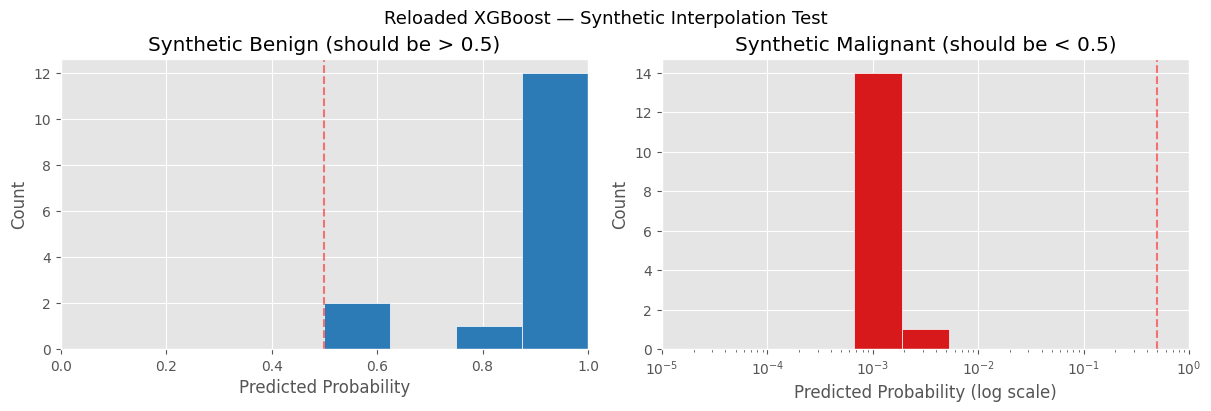

In [25]:
# --- Test reloaded model on synthetic interpolated samples ---
# Select 10 benign, 10 malignant from test set
benign_idx = np.where(y_test == 1)[0][:10]
malignant_idx = np.where(y_test == 0)[0][:10]

rng = np.random.RandomState(99)

# Random pairing within each class
def pair_up(indices):
    idx = indices.copy()
    rng.shuffle(idx)
    return [(idx[i], idx[i + 1]) for i in range(0, len(idx) - 1, 2)]

benign_pairs = pair_up(benign_idx)
malignant_pairs = pair_up(malignant_idx)

# Interpolation ratios (0=source1, 0.5=midpoint, 1=source2)
ratios = [0.25, 0.50, 0.75]

results = []
for (a, b), true_label, class_name in [
    *[(p, 1, 'benign') for p in benign_pairs],
    *[(p, 0, 'malignant') for p in malignant_pairs]
]:
    x1, x2 = X_test[a], X_test[b]
    for r in ratios:
        synth = r * x2 + (1 - r) * x1
        scaled = scaler_reloaded.transform([synth])
        prob = xgb_reloaded.predict_proba(scaled)[0, 1]
        pred = 1 if prob > 0.5 else 0
        results.append((a, b, r, class_name, prob, pred, true_label))

# --- Summary ---
correct = sum(1 for _, _, _, _, _, pred, true in results if pred == true)
total = len(results)
benign_correct = sum(1 for _, _, _, _, _, pred, true in results if true == 1 and pred == 1)
malignant_correct = sum(1 for _, _, _, _, _, pred, true in results if true == 0 and pred == 0)

print(f"Synthetic test: {correct}/{total} correct ({100*correct/total:.1f}%)")
print(f"  Benign:    {benign_correct}/15 correct")
print(f"  Malignant: {malignant_correct}/15 correct")

# --- Detailed table ---
print(f"\n{'Src1':>5} {'Src2':>5} {'Ratio':>6} {'Class':>10} {'Prob':>7} {'Pred':>11} {'Match':>6}")
print("-" * 58)
for a, b, r, cls, prob, pred, true in results:
    match = 'OK' if pred == true else 'FLIP'
    marker = ' !!!' if pred != true else ''
    pred_name = data.target_names[pred]
    print(f"{a:>5d} {b:>5d} {r:>6.2f} {cls:>10} {prob:>7.4f} {pred_name:>11} {match:>6}{marker}")

# --- Confidence histogram ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
benign_probs = [prob for _, _, _, cls, prob, _, _ in results if cls == 'benign']
malignant_probs = [prob for _, _, _, cls, prob, _, _ in results if cls == 'malignant']

# Benign: use linear bins 0-1
axes[0].hist(benign_probs, bins=np.linspace(0, 1, 9), color='#2c7bb6', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('Synthetic Benign (should be > 0.5)')
axes[0].set_xlabel('Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_xlim(0, 1)

# Malignant: use log-spaced bins to show near-zero detail
max_p = max(malignant_probs) if malignant_probs else 1e-3
axes[1].hist(malignant_probs, bins=np.logspace(-5, 0, 12), color='#d7191c', edgecolor='white')
axes[1].set_xscale('log')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('Synthetic Malignant (should be < 0.5)')
axes[1].set_xlabel('Predicted Probability (log scale)')
axes[1].set_ylabel('Count')
axes[1].set_xlim(1e-5, 1)

fig.suptitle('Reloaded XGBoost — Synthetic Interpolation Test', fontsize=13)
plt.show()


Testing 30 samples × 5 noise levels × 5 perturbations

   Noise     Robust    Brittle  Flip Rate
------------------------------------------
     1%        27/30           3/30       13/150 (  8.7%)
     3%        27/30           3/30       14/150 (  9.3%)
     5%        27/30           3/30       13/150 (  8.7%)
    10%        27/30           3/30       11/150 (  7.3%)
    50%        25/30           5/30       13/150 (  8.7%)


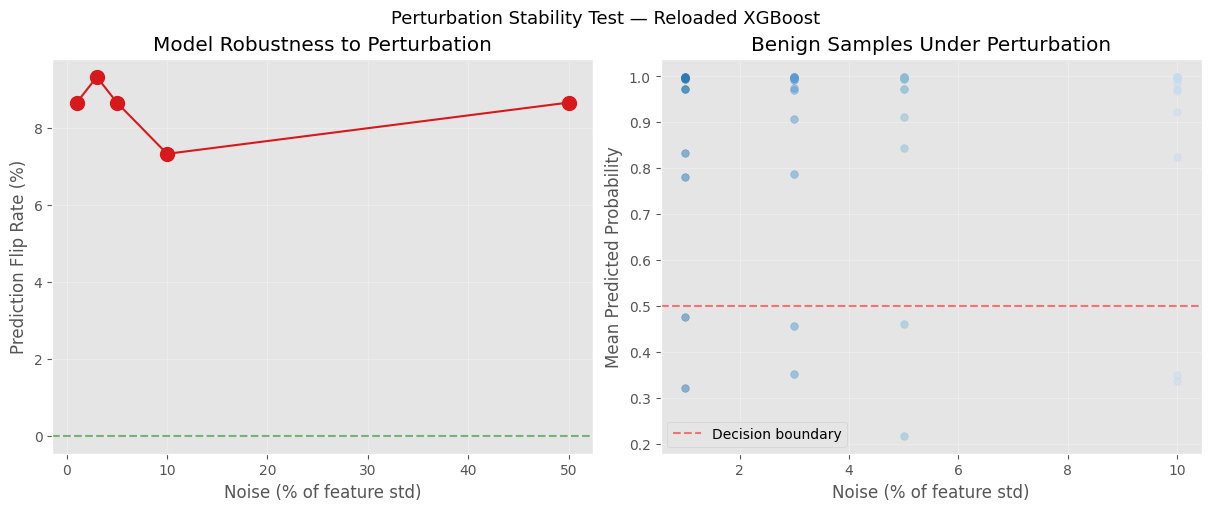

In [26]:
# --- Perturbation test: add noise to known samples ---
# Take 15 benign + 15 malignant from test set, perturb each, check predictions

benign_idx = np.where(y_test == 1)[0][:15]
malignant_idx = np.where(y_test == 0)[0][:15]
test_idx = np.concatenate([benign_idx, malignant_idx])
true_labels = y_test[test_idx]

noise_levels = [0.01, 0.03, 0.05, 0.10, 0.50]  # fraction of feature std
n_perturbations = 5  # noisy copies per sample per noise level
rng = np.random.RandomState(2025)

# Feature std from training set (used to scale noise appropriately)
feat_std = np.std(X_cv, axis=0)

print(f"Testing {len(test_idx)} samples \u00d7 {len(noise_levels)} noise levels \u00d7 {n_perturbations} perturbations\n")

results = []
for idx, true_label in zip(test_idx, true_labels):
    original = X_test[idx]
    for nl in noise_levels:
        flips = 0
        probs = []
        for _ in range(n_perturbations):
            noise = rng.normal(0, nl * feat_std, size=original.shape)
            perturbed = original + noise
            scaled = scaler_reloaded.transform([perturbed])
            prob = xgb_reloaded.predict_proba(scaled)[0, 1]
            probs.append(prob)
            pred = 1 if prob > 0.5 else 0
            if pred != true_label:
                flips += 1
        results.append({
            'idx': idx, 'true_class': data.target_names[true_label],
            'noise_level': nl, 'flips': flips, 'n': n_perturbations,
            'mean_prob': np.mean(probs), 'std_prob': np.std(probs)
        })

# --- Summary per noise level ---
print(f"{'Noise':>8} {'Robust':>10} {'Brittle':>10} {'Flip Rate':>10}")
print("-" * 42)
for nl in noise_levels:
    level_results = [r for r in results if r['noise_level'] == nl]
    total_flips = sum(r['flips'] for r in level_results)
    total_tests = sum(r['n'] for r in level_results)
    robust = sum(1 for r in level_results if r['flips'] == 0)
    brittle = sum(1 for r in level_results if r['flips'] > 0)
    print(f"{nl*100:>6.0f}%  {robust:>8}/{len(level_results):<4}  {brittle:>8}/{len(level_results):<4}  {total_flips:>5}/{total_tests} ({100*total_flips/total_tests:>5.1f}%)")

# --- Visual: flip rate vs noise level ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

flip_rates = []
for nl in noise_levels:
    level_results = [r for r in results if r['noise_level'] == nl]
    total_flips = sum(r['flips'] for r in level_results)
    total_tests = sum(r['n'] for r in level_results)
    flip_rates.append(100 * total_flips / total_tests)

axes[0].plot([nl*100 for nl in noise_levels], flip_rates, 'o-', color='#d7191c', markersize=10)
axes[0].set_xlabel('Noise (% of feature std)')
axes[0].set_ylabel('Prediction Flip Rate (%)')
axes[0].set_title('Model Robustness to Perturbation')
axes[0].grid(alpha=0.3)
axes[0].axhline(0, color='green', linestyle='--', alpha=0.5)

# Probability spread at each noise level for benign samples
for nl, color in zip(noise_levels, ['#2c7bb6', '#5a9bd4', '#8abcd4', '#c6dbef']):
    probs = [r['mean_prob'] for r in results if r['noise_level'] == nl and r['true_class'] == 'benign']
    axes[1].scatter([nl*100]*len(probs), probs, color=color, alpha=0.5, s=30)

axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Decision boundary')
axes[1].set_xlabel('Noise (% of feature std)')
axes[1].set_ylabel('Mean Predicted Probability')
axes[1].set_title('Benign Samples Under Perturbation')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Perturbation Stability Test — Reloaded XGBoost', fontsize=13)
plt.show()
